In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/Colab Notebooks/Ejercicios Python Avanzado/Datasets Repaso-20241010")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
%ls -lisa

total 34553
288   465 -rw------- 1 root root   475149 Oct 10 06:30 accidentes_2022.csv
291  4991 -rw------- 1 root root  5110692 Oct 10 06:46 apartment_cost_list.csv
290   626 -rw------- 1 root root   640957 Oct 10 06:42 Facturacionagua.csv
289 22149 -rw------- 1 root root 22680393 Oct 10 06:36 GlobalLandTemperaturesByCountry.csv
295   388 -rw------- 1 root root   397285 Oct 10 07:01 movies.csv
294  4388 -rw------- 1 root root  4492920 Oct 10 06:59 ProgramLanguages.csv
296   220 -rw------- 1 root root   225102 Oct 10 07:02 UsedCars.csv
292  1325 -rw------- 1 root root  1355781 Oct 10 06:50 vgsales.csv
293     2 -rw------- 1 root root     1412 Oct 10 06:54 WorldCups.csv


In [ ]:
df = pd.read_csv("accidentes_2022.csv")
df.drop(columns=["Unnamed: 0", "incidenceType", "sourceId", "autonomousRegion", "endDate", "incidenceName", "carRegistration", "pkEnd"], inplace=True)
df.rename(columns={"pkStart": "pk"}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3550 entries, 0 to 3549
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   incidenceId     3550 non-null   int64  
 1   province        3550 non-null   object 
 2   cause           3550 non-null   object 
 3   cityTown        3477 non-null   object 
 4   startDate       3550 non-null   object 
 5   incidenceLevel  3492 non-null   object 
 6   road            3550 non-null   object 
 7   pk              3550 non-null   float64
 8   direction       3550 non-null   object 
 9   latitude        3550 non-null   float64
 10  longitude       3550 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 305.2+ KB


In [ ]:
descripcion = df.describe(include="all").T
descripcion["Tipos"] = df.dtypes
descripcion["Nulos"] = df.isna().sum()
descripcion["Únicos"] = df.nunique()
descripcion

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,Tipos,Nulos,Únicos
incidenceId,3550.0,NaN,NaN,NaN,102823.86,20281.898904,55831.0,90958.0,109024.5,116033.75,135240.0,int64,0,3550
province,3550,3,BIZKAIA,1826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,3
cause,3550,5,Alcance,2355,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,5
cityTown,3477,227,Bilbao,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,73,227
startDate,3550,3528,2022-05-18T11:48:49,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,3528
incidenceLevel,3492,4,Blanco,1799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,58,4
road,3550,274,N-634,415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,274
pk,3550.0,NaN,NaN,NaN,83.320282,124.754554,0.0,12.0,30.0,106.0,454.0,float64,0,235
direction,3550,240,SANTANDER,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,240
latitude,3550.0,NaN,NaN,NaN,43.163619,0.184388,42.49788,43.07188,43.2291,43.29587,43.44548,float64,0,1460


In [ ]:
df.set_index("incidenceId")

,province,cause,cityTown,startDate,incidenceLevel,road,pk,direction,latitude,longitude
incidenceId,,,,,,,,,,
135240,GIPUZKOA,Vuelco,Villabona,2022-12-31T19:11:37,Blanco,N-1,443.0,IRÚN,43.19580,-2.048020
135239,BIZKAIA,Vuelco,Gorliz,2022-12-31T19:21:20,Amarillo,BI-2120,25.0,PLENTZIA,43.40304,-2.926750
135238,BIZKAIA,Alcance,Erandio,2022-12-31T19:41:13,Blanco,BI-2704,13.0,PLENTZIA,43.33434,-2.928410
135135,GIPUZKOA,Alcance,Andoain,2022-12-31T16:04:10,Blanco,N-1,446.0,IRÚN,43.21253,-2.030060
135110,BIZKAIA,Alcance,Mundaka,2022-12-31T06:22:18,Blanco,BI-2235,48.0,BERMEO,43.40657,-2.700410
...,...,...,...,...,...,...,...,...,...,...
55847,BIZKAIA,Salida,Bilbao,2022-01-02T12:11:17,NaN,BI-631,6.0,Bermeo,43.26513,-2.907980
55846,ARABA,Vuelco,Legutiano,2022-01-02T12:37:50,Blanco,N-240,22.0,BILBAO,43.16259,-2.779120
55845,ARABA,Vuelco,Legutiano,2022-01-02T12:37:50,Blanco,N-240,22.0,BILBAO,43.01331,-2.683908


# Conversión de startDate en datetime

Hay elementos a los que les faltan los segundos

In [ ]:
df["startDate"][77]

'2022-12-22T09:07'

Corregimos viendo que basta con añadir `:00` a esos elementos

In [ ]:
df.loc[df["startDate"].apply(len)<19, "startDate"] = df.loc[df["startDate"].apply(len)<19, "startDate"] + ":00"
not any(df["startDate"].apply(len)<19)

True

Ya se puede inferir el datetime

In [ ]:
df["startDate"] = pd.to_datetime(df["startDate"], format = "%Y-%m-%dT%H:%M:%S")

In [ ]:
df["startDate"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3550 entries, 0 to 3549
Series name: startDate
Non-Null Count  Dtype         
--------------  -----         
3550 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 27.9 KB


In [ ]:
descripcion = df.describe(include="all").T
descripcion["Tipos"] = df.dtypes
descripcion["Nulos"] = df.isna().sum()
descripcion["Únicos"] = df.nunique()
descripcion

,count,unique,top,freq,mean,min,25%,50%,75%,max,std,Tipos,Nulos,Únicos
incidenceId,3550.0,NaN,NaN,NaN,102823.86,55831.0,90958.0,109024.5,116033.75,135240.0,20281.898904,int64,0,3550
province,3550,3,BIZKAIA,1826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,3
cause,3550,5,Alcance,2355,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,5
cityTown,3477,227,Bilbao,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,73,227
startDate,3550,NaN,NaN,NaN,2022-07-02 05:17:19.574929664,2022-01-01 19:31:17,2022-03-31 18:24:58.249999872,2022-06-26 15:24:14.500000,2022-10-04 11:20:41,2022-12-31 19:41:13,NaN,datetime64[ns],0,3528
incidenceLevel,3492,4,Blanco,1799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,58,4
road,3550,274,N-634,415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,274
pk,3550.0,NaN,NaN,NaN,83.320282,0.0,12.0,30.0,106.0,454.0,124.754554,float64,0,235
direction,3550,240,SANTANDER,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,240
latitude,3550.0,NaN,NaN,NaN,43.163619,42.49788,43.07188,43.2291,43.29587,43.44548,0.184388,float64,0,1460


## Determinación del día con más accidentes

DatetimeIndex(['2022-04-01'], dtype='datetime64[ns]', name='startDate', freq='D')

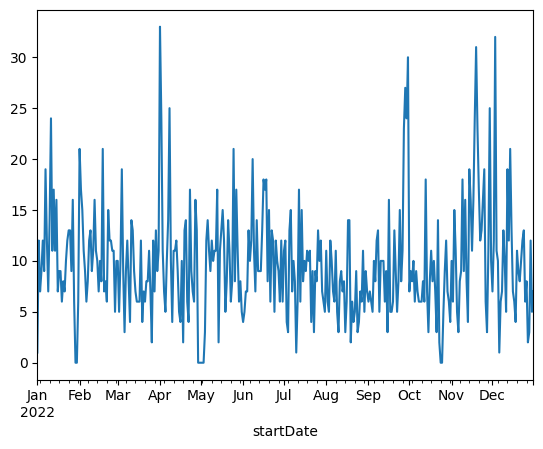

In [ ]:
df_diarios = df.set_index("startDate").resample("D").count()
df_diarios["incidenceId"].plot(kind="line")
df_diarios[df_diarios["incidenceId"] == df_diarios["incidenceId"].max()].index

## Histograma de los accidentes mensuales

<ipython-input-213-897c2f1dc073>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensuales = df.set_index("startDate").resample("M").count()


<Axes: xlabel='startDate'>

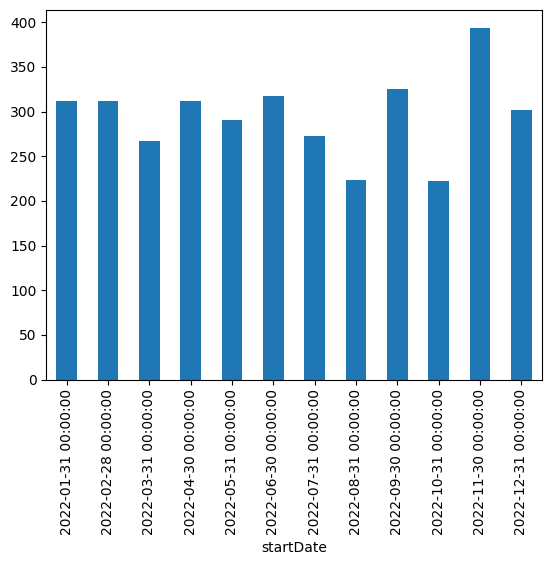

In [ ]:
df_mensuales = df.set_index("startDate").resample("M").count()
df_mensuales["incidenceId"].plot(kind="bar")

<Axes: ylabel='incidenceId'>

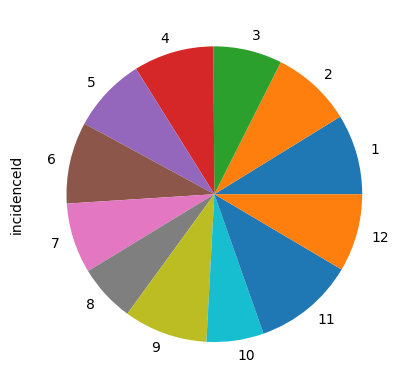

In [ ]:
df["Mes"] = df["startDate"].dt.month
df.groupby("Mes").count()["incidenceId"].plot(kind="pie")

<Axes: ylabel='incidenceId'>

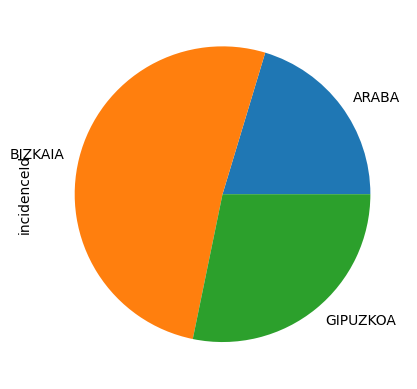

In [ ]:
df.groupby("province").count()["incidenceId"].plot(kind="pie")

## Accidentes por causa

<Axes: xlabel='cause'>

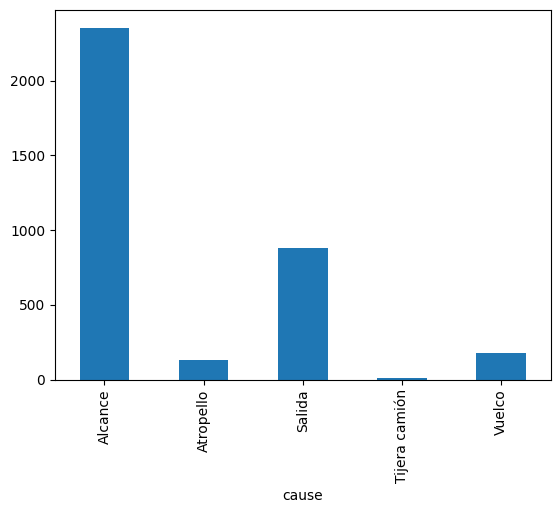

In [ ]:
df.groupby("cause").count()["incidenceId"].plot(kind="bar")

`value_counts()` ordena los valores

In [ ]:
df["cause"]

,cause
0,Vuelco
1,Vuelco
2,Alcance
3,Alcance
4,Alcance
...,...
3545,Salida
3546,Vuelco
3547,Vuelco
3548,Alcance


<Axes: xlabel='cause'>

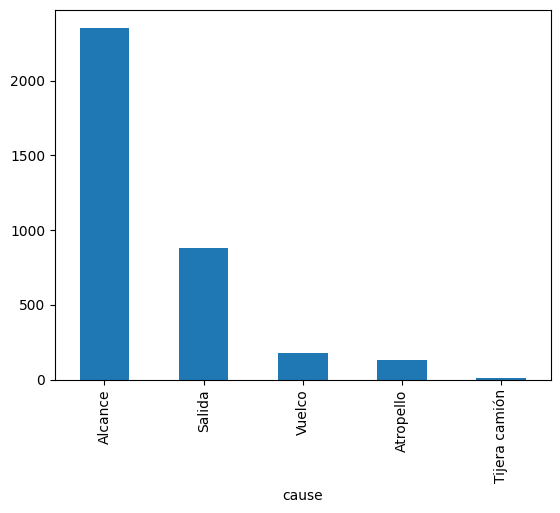

In [ ]:
df["cause"].value_counts().plot(kind="bar")

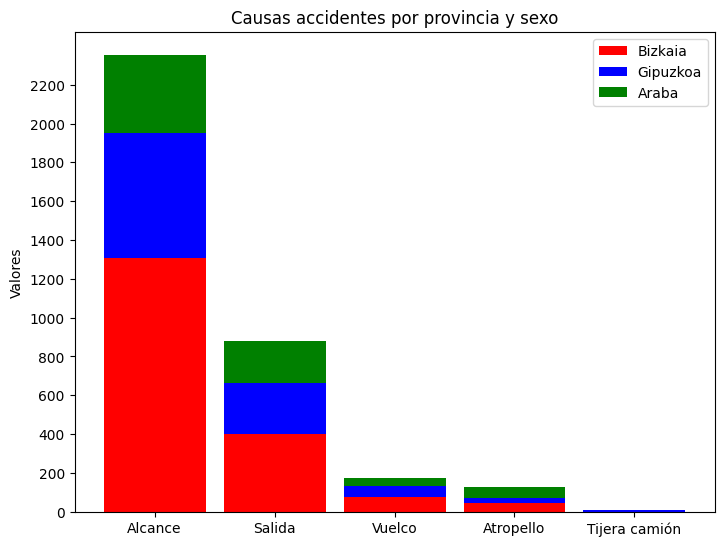

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
datos_BI = df.loc[df["province"]=="BIZKAIA", "cause"].value_counts()
datos_AR = df.loc[df["province"]=="ARABA", "cause"].value_counts()
datos_AR = datos_AR.reindex(datos_BI.index, fill_value=0)
datos_GI = df.loc[df["province"]=="GIPUZKOA", "cause"].value_counts()
ind = np.arange(5)
width = .85
fig=plt.figure()
ax=fig.add_axes([0,0,1,1])
ax.bar(ind, datos_BI, width, color='r')
ax.bar(ind, datos_GI, width, bottom=datos_BI, color='b') # usamos botom para definir la posición de partida de los segundos datos.
ax.bar(ind, datos_AR, width, bottom=(datos_BI + datos_GI), color='g')
ax.set_ylabel('Valores')
ax.set_title('Causas accidentes por provincia y sexo')
ax.set_xticks(ind)
ax.set_xticklabels(datos_BI.index)
ax.set_yticks(np.arange(0, df["cause"].value_counts().max(), 200))
ax.legend(labels=['Bizkaia', 'Gipuzkoa', "Araba"])
plt.show()

Mejorado

In [ ]:
df.loc[0,"cause"] = "Choque con cebra"

In [ ]:
df["province"].unique()

array(['GIPUZKOA', 'BIZKAIA', 'ARABA'], dtype=object)

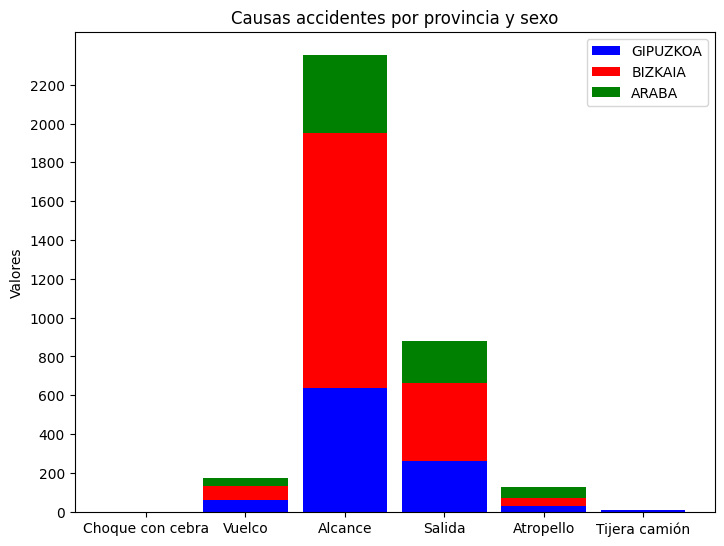

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
datos_GI = df.loc[df["province"]==df["province"].unique()[0], "cause"].value_counts().reindex(df["cause"].unique(), fill_value=0)
datos_BI = df.loc[df["province"]==df["province"].unique()[1], "cause"].value_counts().reindex(df["cause"].unique(), fill_value=0)
datos_AR = df.loc[df["province"]==df["province"].unique()[2], "cause"].value_counts().reindex(df["cause"].unique(), fill_value=0)
ind = np.arange(df["cause"].nunique())
width = .85
fig=plt.figure()
ax=fig.add_axes([0,0,1,1])
ax.bar(ind, datos_GI, width, color='b')
ax.bar(ind, datos_BI, width, bottom=datos_GI, color='r') # usamos botom para definir la posición de partida de los segundos datos.
ax.bar(ind, datos_AR, width, bottom=(datos_BI + datos_GI), color='g')
ax.set_ylabel('Valores')
ax.set_title('Causas accidentes por provincia y sexo')
ax.set_xticks(ind)
ax.set_xticklabels(datos_BI.index)
ax.set_yticks(np.arange(0, df["cause"].value_counts().max(), 200))
ax.legend(labels=df["province"].unique())
plt.show()

In [ ]:
df_num = df[df.describe().columns]
df_num.corr()

,incidenceId,startDate,pk,latitude,longitude,Mes
incidenceId,1.000000,0.926960,0.018675,0.003807,0.010649,0.924420
startDate,0.926960,1.000000,0.014573,0.020668,-0.014546,0.996810
pk,0.018675,0.014573,1.000000,-0.049906,0.254210,0.011579
latitude,0.003807,0.020668,-0.049906,1.000000,-0.136556,0.020408
longitude,0.010649,-0.014546,0.254210,-0.136556,1.000000,-0.017217
Mes,0.924420,0.996810,0.011579,0.020408,-0.017217,1.000000


<Axes: >

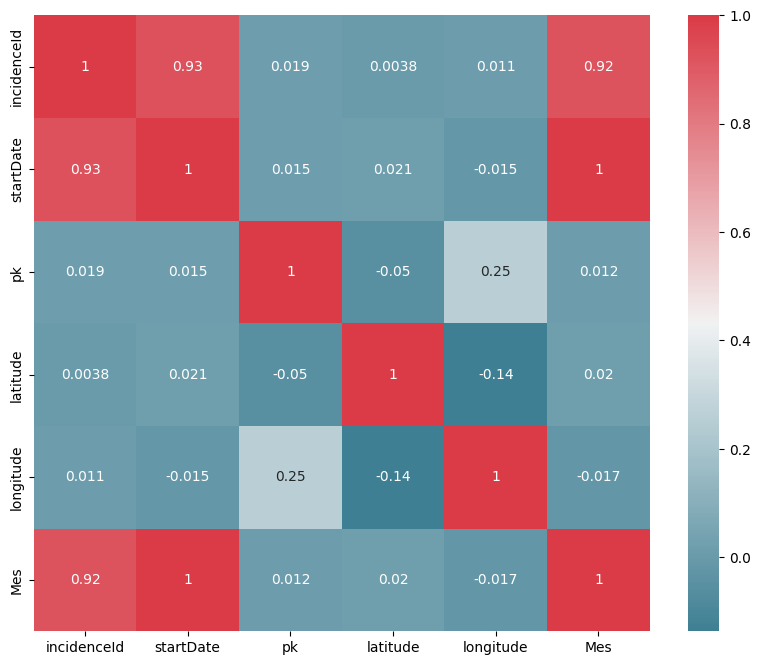

In [ ]:
import seaborn as sns
f, ax = plt.subplots(figsize=(10, 8))
corr = df_num.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(220, 10, as_cmap=True),annot=True, square=True, ax=ax)

## Mapas

In [ ]:
#!pip install folium

import folium
from folium.plugins import HeatMap

# Crear el mapa centrado en una ubicación específica del coordenadas del País Vasco
mapa_accidentes = folium.Map(location=[43, -2.6], zoom_start=9.5)

# Crear una lista de coordenadas (latitud, longitud) para los accidentes
coordenadas_accidentes = df[['latitude', 'longitude']].dropna().values.tolist()

# Añadir las ubicaciones de los accidentes al mapa con marcadores de calor
HeatMap(coordenadas_accidentes).add_to(mapa_accidentes)

# Mostrar el mapa
mapa_accidentes

In [ ]:
#!pip install folium

import folium
from folium.plugins import MarkerCluster

# Crear el mapa centrado en una ubicación específica del coordenadas del País Vasco
mapa_accidentes = folium.Map(location=[43, -2.6], zoom_start=9.5)

# Crear una lista de coordenadas (latitud, longitud) para los accidentes
coordenadas_accidentes = df[['latitude', 'longitude']].dropna().values.tolist()

# Añadir las ubicaciones de los accidentes al mapa con marcadores de calor
MarkerCluster(coordenadas_accidentes).add_to(mapa_accidentes)

# Mostrar el mapa
mapa_accidentes